**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.notebook import trange, tqdm
import os
import random
from LCNN_backend import LCNN
from sklearn.model_selection import train_test_split


**Parameters for data preprocessing**

In [2]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000    
# 
DATASET_MAP = {
    'asv2019': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_train_set_with_delta\\lfcc_tensors_train_set_with_delta',
        'dev': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_dev_set_with_delta\\lfcc_tensors_dev_set_with_delta',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_eval_set_with_delta\\lfcc_tensors_eval_set_with_delta'
    },
    'add2022': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_train',
        'dev':   'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_dev',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_eval',
    },
    'itw': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\itw_lfcc_with_delta',
    }
}                                                  

CURRENT_DATA = 'asv2019'
if CURRENT_DATA != 'itw':
    train_path = DATASET_MAP[CURRENT_DATA]['train']
    dev_path = DATASET_MAP[CURRENT_DATA]['dev']
else:
    train_path = DATASET_MAP[CURRENT_DATA]['train']


**Preprocessing of training data** 

In [3]:
# Set the number of files to pick and the random seed
random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(train_path) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

if CURRENT_DATA == 'itw':
    train_files, dev_files = train_test_split(all_files, test_size=0.4, random_state=random_seed)
    dev_files, eval_files = train_test_split(dev_files, test_size=0.5, random_state=random_seed)
else:
    train_files = all_files
    
# Select the first file from the random selection
inspect_file = os.path.join(train_path, train_files[0])  

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in train_files:
    file_path = os.path.join(train_path, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-4.2530e+02, -4.1924e+02, -3.9770e+02,  ...,  6.0272e+01,
          6.8002e+01,  2.5774e+01],
        [ 1.6841e+01,  2.4703e+01,  4.3698e+01,  ..., -3.0947e+01,
          3.3626e+01,  8.9386e+01],
        [ 1.6329e+01,  2.2457e+01,  2.8052e+01,  ..., -8.7384e+00,
         -5.5001e+00, -8.3772e+00],
        ...,
        [ 1.5694e-01,  1.5694e-01,  1.5694e-01,  ...,  7.2835e-01,
          7.2835e-01,  7.2835e-01],
        [-4.2251e-01, -4.2251e-01, -4.2251e-01,  ...,  1.1511e+00,
          1.1511e+00,  1.1511e+00],
        [-4.1666e-01, -4.1666e-01, -4.1666e-01,  ...,  1.4123e-02,
          1.4123e-02,  1.4123e-02]])
Example of the features tensor([[-2.8503e+02, -2.9261e+02, -3.0101e+02,  ..., -1.7056e+02,
         -1.3316e+00,  4.3546e+01],
        [ 6.4047e+01,  6.1352e+01,  5.7275e+01,  ...,  1.0076e+02,
          1.2351e+02,  1.2853e+02],
        [ 2.7008e+01,  3.0462e+01,  3.2180e+01,  ...,  4.3480e+01,
          4.7021e+01,  4.5388e+01],
        ...

**Dataset inspection**

In [4]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([120, 126])
First sample values:
 tensor([[-4.2530e+02, -4.1924e+02, -3.9770e+02,  ...,  6.0272e+01,
          6.8002e+01,  2.5774e+01],
        [ 1.6841e+01,  2.4703e+01,  4.3698e+01,  ..., -3.0947e+01,
          3.3626e+01,  8.9386e+01],
        [ 1.6329e+01,  2.2457e+01,  2.8052e+01,  ..., -8.7384e+00,
         -5.5001e+00, -8.3772e+00],
        ...,
        [ 1.5694e-01,  1.5694e-01,  1.5694e-01,  ...,  7.2835e-01,
          7.2835e-01,  7.2835e-01],
        [-4.2251e-01, -4.2251e-01, -4.2251e-01,  ...,  1.1511e+00,
          1.1511e+00,  1.1511e+00],
        [-4.1666e-01, -4.1666e-01, -4.1666e-01,  ...,  1.4123e-02,
          1.4123e-02,  1.4123e-02]])
Sample Labels:
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 

**Testing the Data Loader**

In [5]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

120
torch.Size([25380, 120, 126])
Batch features shape: torch.Size([64, 120, 126])


**Preprocessing and loading the Development/Validation Set**

In [6]:
# Set the number of files to pick and the random seed
#random_seed = 42

if CURRENT_DATA == 'itw':
    target_dev_files = dev_files
    target_dev_path = train_path
else:
    target_dev_files = [f for f in os.listdir(dev_path) if f.endswith('.pt')]
    target_dev_path = dev_path

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(target_dev_path, target_dev_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in target_dev_files:
    file_path = os.path.join(target_dev_path, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-3.4720e+02, -2.3046e+02, -1.0462e+02,  ...,  1.1186e+02,
          2.6001e+01,  8.7326e+00],
        [ 3.2223e+01,  1.2686e+02,  2.0104e+02,  ...,  1.2657e+02,
          2.1654e+02,  1.7764e+02],
        [ 2.9802e+01,  1.3691e+01, -1.7798e+01,  ...,  2.6378e+01,
         -2.6602e+01, -1.9582e+01],
        ...,
        [ 4.4822e-02,  4.4822e-02,  4.4822e-02,  ..., -2.4546e-01,
         -2.4546e-01, -2.4546e-01],
        [ 2.2051e-01,  2.2051e-01,  2.2051e-01,  ...,  1.9237e-02,
          1.9237e-02,  1.9237e-02],
        [ 2.7726e-01,  2.7726e-01,  2.7726e-01,  ..., -1.9239e-01,
         -1.9239e-01, -1.9239e-01]])
Example of the features tensor([[-3.6207e+02, -3.6978e+02, -3.7621e+02,  ...,  1.1933e+02,
          1.0973e+02,  9.4715e+01],
        [ 3.6911e+01,  2.8239e+01,  1.9419e+01,  ..., -7.6180e+01,
         -4.8228e+01, -1.2535e+01],
        [ 3.1199e+01,  2.7093e+01,  1.9052e+01,  ..., -5.6702e+01,
         -4.7041e+01, -4.1919e+01],
        ...

**Testing the Processed Dataloaders and Label Distribution**

In [7]:
# print("Training features shape",features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
# print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] n_lfcc | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

# print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Development features shape: torch.Size([24844, 120, 126]) [1] batch size | [2] n_lfcc | [3] Timeframes
Development labels shape: torch.Size([24844])
Validation label distribution: tensor([22296,  2548])


**Initializing LCNN Model**

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lcnn = LCNN().to(device)

In [9]:
# initialize weight
def init_weights(module):
    if isinstance(module, nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            module.bias.data.fill_(0.01)
    elif isinstance(module, nn.Conv2d):
        torch.nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')

lcnn.apply(init_weights)

LCNN(
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv1): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (batchnorm6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv7): Conv2d(32, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool9): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (batchnorm10): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv11): Conv2d(48, 96, kernel_size=(1, 1), stride=(1, 1))
  (batchnorm13): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv14): Conv2d(48, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool16): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv

**Calculate the weights proportion for later use**

In [ ]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the training Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


class_weights = len(labels) / (counts.float() * 2)

class_weights = torch.tensor(class_weights)
print("Weight tensor to be passed to the Loss Function", class_weights)


Proportion of the training Set:
 Spoof: 87.50% | Bonafide: 12.50%
Weight tensor to be passed to the Loss Function tensor([0.5714, 4.0000], device='cuda:0')


C:\Users\Zheng\AppData\Local\Temp\ipykernel_3620\1420130795.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights = torch.tensor(class_weights)


**Loss function and Optimizer**

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))  # Binary cross-entropy loss
optimizer = optim.AdamW(lcnn.parameters(), lr=1e-4, weight_decay=1e-3)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [12]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 15  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



In [13]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)

    if len(thresholds) > 0:
        thresholds[0] = max(scores)

    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))

    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    
    return eer * 100, thresholds[eer_idx]

**Training Loop**

In [14]:

# Training loop
num_epochs = 150


for epoch in range(num_epochs):
    lcnn.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = lcnn(features)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lcnn.parameters(), max_norm=1.0)
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = outputs.argmax(dim=1)
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    lcnn.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = lcnn(features)
            loss = criterion(outputs, labels)

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = outputs.argmax(dim=1)
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            prob = torch.softmax(outputs, dim=1) # extract class 1 score
            score = prob[:,1].cpu().numpy() # extract true label

            all_scores.extend(score)
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}% | "
          f"Val Threshold: {threshold_val:.2f}%")

    # Learning rate scheduling
    scheduler.step()

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        
        # Save the threshold to a file
        with open('lcnn_asv_best_threshold.txt', 'w') as f:
            f.write(f"Threshold: {best_threshold}\n")
            f.write(f"Best EER: {best_eer}\n")
        counter = 0

        # save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': lcnn.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_eer': best_eer,
            'best_threshold': best_threshold,
            'counter': counter # To resume early stopping patience
        }
        torch.save(checkpoint, 'lcnn_asv_checkpoint.pth')
        
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break

Epoch [1/150] | Train Loss: 0.3078, Acc: 80.66% | Val Loss: 0.0453, Acc: 99.37% | Val EER: 0.40% | Val Threshold: 0.60%
Epoch [2/150] | Train Loss: 0.0852, Acc: 96.99% | Val Loss: 0.0186, Acc: 99.45% | Val EER: 0.50% | Val Threshold: 0.57%
EER not improved. Patience counter: 1/15
Epoch [3/150] | Train Loss: 0.0218, Acc: 99.47% | Val Loss: 0.0183, Acc: 99.67% | Val EER: 0.51% | Val Threshold: 0.07%
EER not improved. Patience counter: 2/15
Epoch [4/150] | Train Loss: 0.0120, Acc: 99.74% | Val Loss: 0.0103, Acc: 99.75% | Val EER: 0.27% | Val Threshold: 0.37%
Epoch [5/150] | Train Loss: 0.0098, Acc: 99.83% | Val Loss: 0.0107, Acc: 99.76% | Val EER: 0.28% | Val Threshold: 0.36%
EER not improved. Patience counter: 1/15
Epoch [6/150] | Train Loss: 0.0067, Acc: 99.86% | Val Loss: 0.0356, Acc: 99.50% | Val EER: 0.69% | Val Threshold: 0.07%
EER not improved. Patience counter: 2/15
Epoch [7/150] | Train Loss: 0.0026, Acc: 99.94% | Val Loss: 0.0135, Acc: 99.90% | Val EER: 0.20% | Val Threshold: 0.

**Plotting the results**

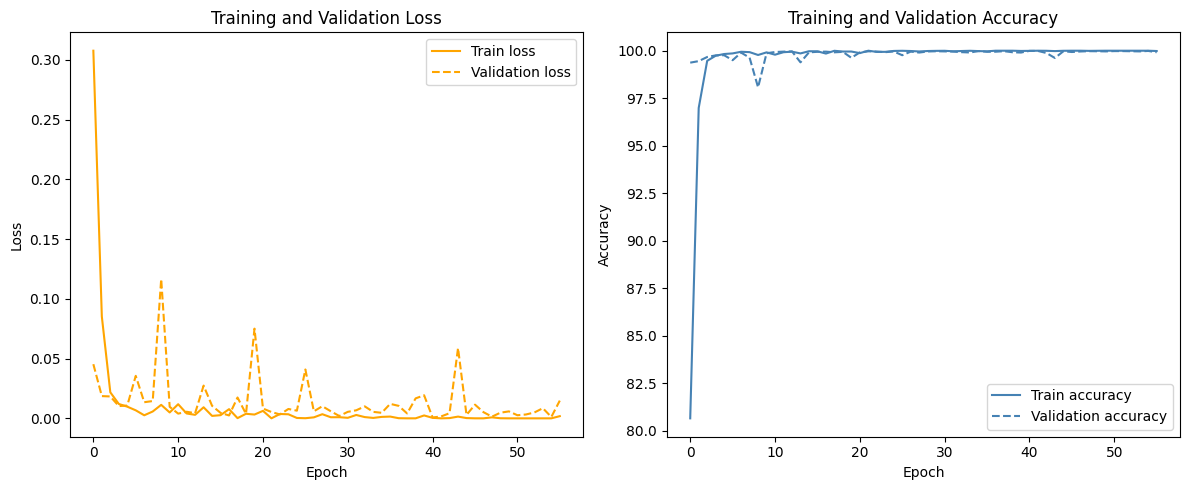

In [15]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Prepare Evaluation Dataset**

In [16]:


# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
if CURRENT_DATA == "itw":
    target_eval_files = eval_files
    target_eval_path = train_path
else:
    target_eval_path = DATASET_MAP[CURRENT_DATA]['eval']
    target_eval_files = [f for f in os.listdir(target_eval_path) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(target_eval_path, target_eval_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in target_eval_files:
    file_path = os.path.join(target_eval_path, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=64, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([[-3.1719e+02, -1.8039e+02, -6.8076e+01,  ..., -4.5134e+01,
         -3.8520e+01, -1.7389e+01],
        [ 8.4354e+01,  1.6613e+02,  2.0741e+02,  ...,  2.5119e+02,
          2.3634e+02,  2.3194e+02],
        [ 4.2919e+01,  3.2076e+01,  1.4553e+01,  ..., -4.7070e+00,
         -1.9970e+00, -8.4831e-02],
        ...,
        [ 1.7571e-02,  1.7571e-02,  1.7571e-02,  ...,  2.3086e-01,
          2.3086e-01,  2.3086e-01],
        [-4.9345e-01, -4.9345e-01, -4.9345e-01,  ...,  2.9802e-01,
          2.9802e-01,  2.9802e-01],
        [-1.0044e-01, -1.0044e-01, -1.0044e-01,  ...,  5.3810e-02,
          5.3810e-02,  5.3810e-02]])
Example of the features tensor([[-3.3888e+02, -3.7314e+02, -2.9060e+02,  ..., -3.8714e+02,
         -3.9049e+02, -3.9146e+02],
        [ 3.6489e+01,  3.1510e+01,  9.5408e+01,  ...,  2.2135e+01,
          1.7525e+01,  1.6173e+01],
        [ 1.3734e+01,  1.6058e+01,  4.1746e+01,  ...,  2.1536e+01,
          1.7273e+01,  1.5978e+01],
        ...

In [17]:
import numpy as np

model = LCNN().to(device)

checkpoint = torch.load('lcnn_asv_checkpoint.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])



<All keys matched successfully>


Evaluation Set:
Loss: 3.7931 | Accuracy: 84.29%
EER: 10.88% | Optimal Probability Threshold: 1.0000
F1 Score: 0.5558 | Precision: 0.3924 | Recall: 0.9520
Predictions Distribution -> [1/Bonafide]: 17843 | [0/Spoof]: 53394


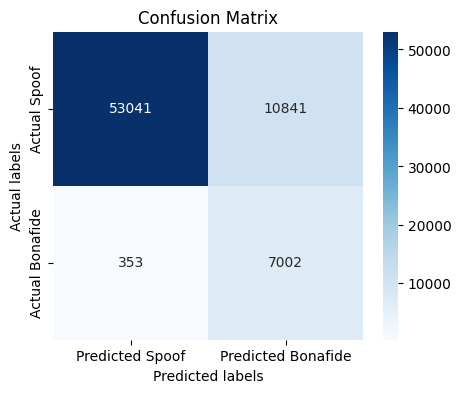

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            
            # Use labels.float().unsqueeze(1) to match BCEWithLogitsLoss expectations
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            prob = torch.softmax(outputs, dim=1) # extract class 1 score
            score = prob[:,1].cpu().numpy() # extrac true label

            all_scores.extend(score)
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # 1. Calculate EER and the optimal Threshold first
    eer, threshold = calculate_eer(all_labels, all_scores)
    
    # 2. Use the EER threshold for ALL metrics to stay consistent
    preds = (all_scores >= threshold).astype(int)
    
    # 3. Calculate consistent metrics
    avg_loss = total_loss / len(eval_dataLoader)
    correct = (preds == all_labels).sum()
    accuracy = 100 * correct / len(all_labels)
    
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Optimal Probability Threshold: {threshold:.4f}")
    print(f"F1 Score: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
    print(f"Predictions Distribution -> [1/Bonafide]: {np.count_nonzero(preds == 1)} | [0/Spoof]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Spoof', 'Predicted Bonafide'],
                yticklabels=['Actual Spoof', 'Actual Bonafide'])
    plt.xlabel('Predicted labels')
    plt.ylabel('Actual labels')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(model, eval_dataLoader)